<a href="https://colab.research.google.com/github/vikagrishina/My_First_Test_Repo/blob/main/LR3_Energy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Библиотеки успешно загружены!
Исходные данные:
            0         1
0  01.01.2013  103256.7
1  01.02.2013   91532.6
2  01.03.2013   97809.1
3  01.04.2013   85131.0
4  01.05.2013   79080.8
5  01.06.2013   74479.9
6  01.07.2013   76095.4
7  01.08.2013   76872.0
8  01.09.2013   79531.2
9  01.10.2013   90408.8

Размер таблицы: (84, 2)
Количество столбцов: 2

Обнаружено 2 столбца: Дата и Выработка

После переименования:
         Дата  Выработка_кВтч
0  01.01.2013        103256.7
1  01.02.2013         91532.6
2  01.03.2013         97809.1
3  01.04.2013         85131.0
4  01.05.2013         79080.8
5  01.06.2013         74479.9
6  01.07.2013         76095.4
7  01.08.2013         76872.0
8  01.09.2013         79531.2
9  01.10.2013         90408.8

Результат разделения даты:
    0   1     2
0  01  01  2013
1  01  02  2013
2  01  03  2013
3  01  04  2013
4  01  05  2013

Обработанные данные:
   Выработка_млн_кВтч  Месяц   Год
0            103.2567      1  2013
1             91.5326      2  20

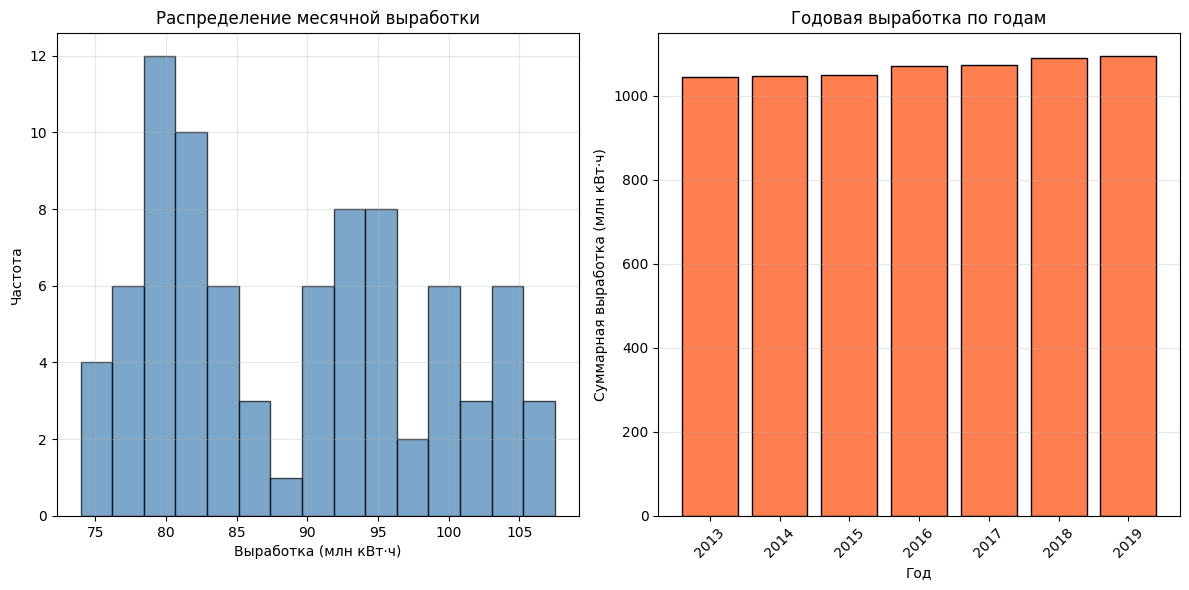


4.7. Построение круговой диаграммы


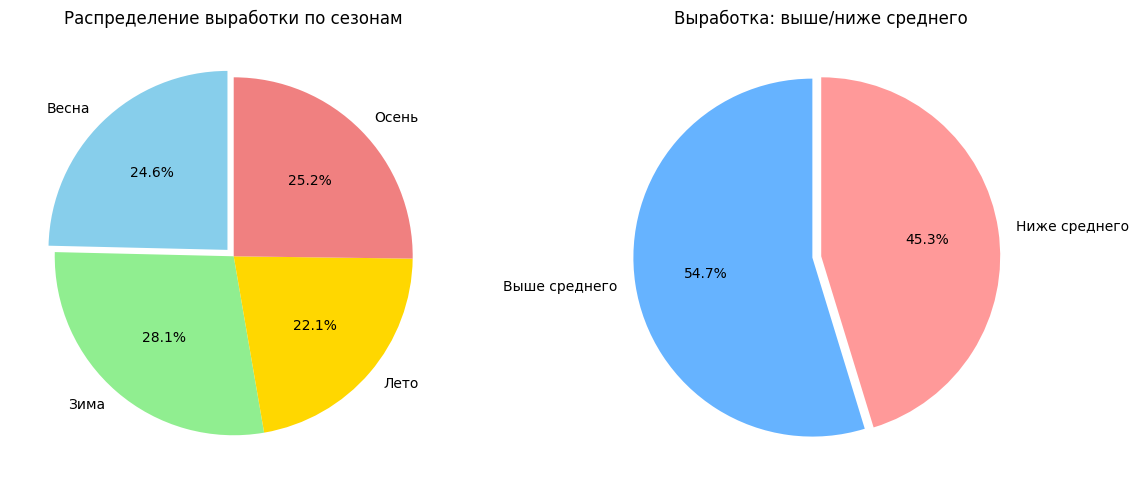


4.8. Построение интерактивного графика
Не удалось построить интерактивный график: unexpected attribute 'plot_width' to figure, similar attributes are outer_width, width or min_width
Строим обычный график...


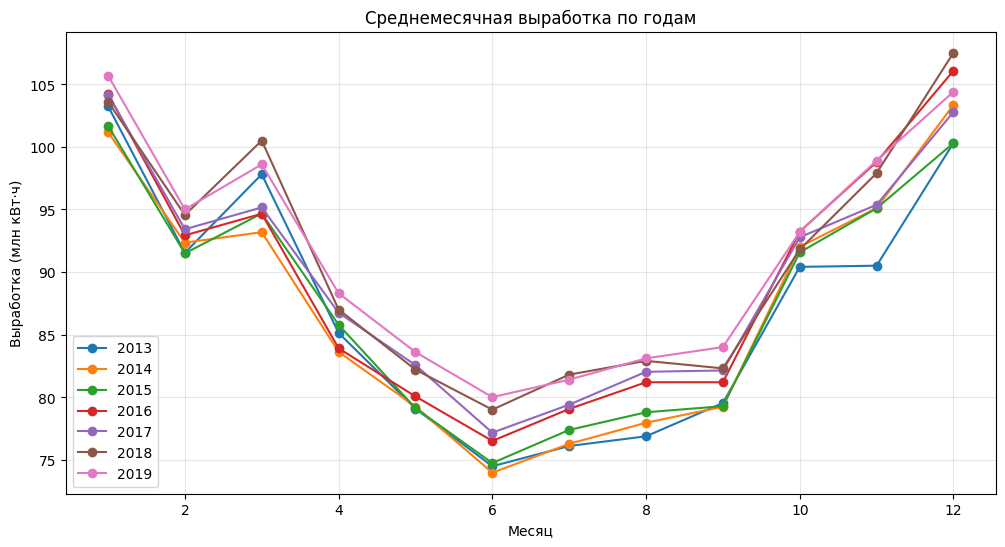


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА

Общая информация о данных:
  - Всего наблюдений: 84
  - Период: 2013 - 2019 г.
  - Средняя выработка: 88.99 млн кВт·ч
  - Максимальная выработка: 107.52 млн кВт·ч
  - Минимальная выработка: 73.96 млн кВт·ч
  - Стандартное отклонение: 9.49

Топ-5 месяцев по выработке:
  2018 г., месяц 12: 107.52 млн кВт·ч (Зима)
  2016 г., месяц 12: 106.08 млн кВт·ч (Зима)
  2019 г., месяц 1: 105.70 млн кВт·ч (Зима)
  2019 г., месяц 12: 104.40 млн кВт·ч (Зима)
  2016 г., месяц 1: 104.24 млн кВт·ч (Зима)

Работа успешно выполнена!


In [3]:
# Лабораторная работа №3
# Работа с табличными данными на Python
# Тема: Анализ данных генерации электроэнергии в России

# ============================================
# 1. Подключение необходимых библиотек
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show, output_notebook
from bokeh.io import output_notebook
import requests

# Настройка отображения графиков в Colab
output_notebook()

print("Библиотеки успешно загружены!")

# ============================================
# 2. Получение данных (Web-scraping)
# ============================================
# Данные о выработке электроэнергии в России по месяцам
# Источник: Министерство энергетики РФ

# Чтение данных из Excel-файла
url_excel = 'https://drive.google.com/uc?export=download&id=1IFULWv72kGpZRDRpqRskm5NIM6AOCFPR'
df_init = pd.read_excel(url_excel, header=None)

print("Исходные данные:")
print(df_init.head(10))
print(f"\nРазмер таблицы: {df_init.shape}")
print(f"Количество столбцов: {df_init.shape[1]}")

# ============================================
# 3. Предобработка данных (ИСПРАВЛЕНО)
# ============================================

# Проверяем, сколько столбцов в данных
n_columns = df_init.shape[1]

if n_columns == 2:
    # Если 2 столбца: дата и выработка
    df_init.columns = ['Дата', 'Выработка_кВтч']
    print("\nОбнаружено 2 столбца: Дата и Выработка")
elif n_columns == 3:
    # Если 3 столбца: дата, выработка и что-то еще
    df_init.columns = ['Дата', 'Выработка_кВтч', 'Показатель']
    print("\nОбнаружено 3 столбца")
else:
    # Если другое количество, используем только первые два
    df_init = df_init.iloc[:, :2]
    df_init.columns = ['Дата', 'Выработка_кВтч']
    print(f"\nОбнаружено {n_columns} столбцов, используем первые 2")

print("\nПосле переименования:")
print(df_init.head(10))

# Извлечение года и месяца из даты
# Дата в формате ДД.ММ.ГГГГ
df_date = df_init['Дата'].astype(str).str.split('.', expand=True)

# Проверяем, успешно ли разделили
print("\nРезультат разделения даты:")
print(df_date.head())

# Создание итоговой таблицы
df_energy = pd.DataFrame()
df_energy['Выработка_млн_кВтч'] = df_init['Выработка_кВтч'] / 1000  # перевод в млн кВт·ч
df_energy['Месяц'] = df_date[1].astype(int)
df_energy['Год'] = df_date[2].astype(int)

# Удаление строк с некорректными данными
df_energy = df_energy.dropna()
df_energy = df_energy[df_energy['Выработка_млн_кВтч'] > 0]

print("\nОбработанные данные:")
print(df_energy.head(10))
print(f"\nДиапазон данных: {df_energy['Год'].min()} - {df_energy['Год'].max()}")
print(f"Всего записей: {len(df_energy)}")

# ============================================
# 4.1. Сортировка данных
# ============================================

print("\n" + "="*50)
print("4.1. Сортировка данных")
print("="*50)

# Сортировка по выработке (по убыванию)
df_sorted_by_gen = df_energy.sort_values('Выработка_млн_кВтч', ascending=False)
print("Топ-5 месяцев по выработке электроэнергии:")
print(df_sorted_by_gen.head(5))

# Сортировка по году и месяцу
df_sorted_by_date = df_energy.sort_values(['Год', 'Месяц'])
print("\nДанные, отсортированные по дате (первые 10 строк):")
print(df_sorted_by_date.head(10))

# ============================================
# 4.2. Добавление столбца с новыми данными
# ============================================

print("\n" + "="*50)
print("4.2. Добавление нового столбца")
print("="*50)

# Функция определения сезона по месяцу
def get_season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'

# Добавление столбца с сезоном
df_energy['Сезон'] = df_energy['Месяц'].apply(get_season)

# Добавление столбца с категорией (высокая/низкая выработка)
median_gen = df_energy['Выработка_млн_кВтч'].median()
df_energy['Категория'] = np.where(
    df_energy['Выработка_млн_кВтч'] > median_gen,
    'Выше среднего',
    'Ниже среднего'
)

print("Таблица с добавленными столбцами:")
print(df_energy.head(10))
print(f"\nМедианное значение выработки: {median_gen:.2f} млн кВт·ч")

# ============================================
# 4.3. Выбор фрагмента таблицы по условию
# ============================================

print("\n" + "="*50)
print("4.3. Выборка по условию")
print("="*50)

# Выборка: годы с 2014 по 2016
if df_energy['Год'].max() >= 2016:
    df_selected_years = df_energy[(df_energy['Год'] >= 2014) & (df_energy['Год'] <= 2016)]
    print("Данные за 2014-2016 годы (первые 10 строк):")
    print(df_selected_years.head(10))
    print(f"Всего записей: {len(df_selected_years)}")
else:
    print(f"Доступные годы: {df_energy['Год'].min()} - {df_energy['Год'].max()}")

# Выборка: зимние месяцы с выработкой выше среднего
avg_gen = df_energy['Выработка_млн_кВтч'].mean()
df_winter_high = df_energy[(df_energy['Сезон'] == 'Зима') & (df_energy['Выработка_млн_кВтч'] > avg_gen)]
print(f"\nЗимние месяцы с выработкой выше средней ({avg_gen:.0f} млн кВт·ч):")
print(df_winter_high)

# ============================================
# 4.4. Выбор фрагмента по номерам строк и столбцов (iloc)
# ============================================

print("\n" + "="*50)
print("4.4. Выборка по номерам строк и столбцов (iloc)")
print("="*50)

# Выбор первых 5 строк и столбцов 0-2
print("Первые 5 строк, столбцы 0-2:")
print(df_energy.iloc[0:5, 0:3])

# Выбор строк с 10 по 15 и столбцов 1 и 3
if len(df_energy) >= 16:
    print("\nСтроки 10-15, столбцы 1 и 3 (Месяц и Год):")
    print(df_energy.iloc[10:16, [1, 3]])

# Выбор каждой 3-й строки
print("\nКаждая 3-я строка (первые 10):")
print(df_energy.iloc[::3, :].head(10))

# ============================================
# 4.5. Статистика по сгруппированным данным
# ============================================

print("\n" + "="*50)
print("4.5. Статистика по сгруппированным данным")
print("="*50)

# Группировка по годам
yearly_stats = df_energy.groupby('Год')['Выработка_млн_кВтч'].agg(['sum', 'mean', 'max', 'min', 'count'])
print("Статистика по годам:")
print(yearly_stats.round(2))

# Группировка по месяцам
monthly_stats = df_energy.groupby('Месяц')['Выработка_млн_кВтч'].agg(['mean', 'sum'])
print("\nСредняя выработка по месяцам:")
print(monthly_stats.round(2))

# Группировка по сезонам
if 'Сезон' in df_energy.columns:
    seasonal_stats = df_energy.groupby('Сезон')['Выработка_млн_кВтч'].agg(['mean', 'sum', 'max'])
    print("\nСтатистика по сезонам:")
    print(seasonal_stats.round(2))

# ============================================
# 4.6. Гистограмма
# ============================================

print("\n" + "="*50)
print("4.6. Построение гистограммы")
print("="*50)

plt.figure(figsize=(12, 6))

# Гистограмма распределения выработки
plt.subplot(1, 2, 1)
plt.hist(df_energy['Выработка_млн_кВтч'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Выработка (млн кВт·ч)')
plt.ylabel('Частота')
plt.title('Распределение месячной выработки')
plt.grid(True, alpha=0.3)

# Гистограмма по годам (суммарная)
plt.subplot(1, 2, 2)
yearly_sum = df_energy.groupby('Год')['Выработка_млн_кВтч'].sum()
plt.bar(yearly_sum.index.astype(str), yearly_sum.values, color='coral', edgecolor='black')
plt.xlabel('Год')
plt.ylabel('Суммарная выработка (млн кВт·ч)')
plt.title('Годовая выработка по годам')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# 4.7. Круговая диаграмма
# ============================================

print("\n" + "="*50)
print("4.7. Построение круговой диаграммы")
print("="*50)

plt.figure(figsize=(12, 5))

# Круговая диаграмма по сезонам
if 'Сезон' in df_energy.columns:
    plt.subplot(1, 2, 1)
    seasonal_sum = df_energy.groupby('Сезон')['Выработка_млн_кВтч'].sum()
    colors = ['skyblue', 'lightgreen', 'gold', 'lightcoral']
    plt.pie(seasonal_sum.values, labels=seasonal_sum.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0, 0, 0))
    plt.title('Распределение выработки по сезонам')

# Круговая диаграмма по категориям
plt.subplot(1, 2, 2)
category_sum = df_energy.groupby('Категория')['Выработка_млн_кВтч'].sum()
plt.pie(category_sum.values, labels=category_sum.index, autopct='%1.1f%%',
        colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.05, 0))
plt.title('Выработка: выше/ниже среднего')

plt.tight_layout()
plt.show()

# ============================================
# 4.8. Интерактивный график (Bokeh)
# ============================================

print("\n" + "="*50)
print("4.8. Построение интерактивного графика")
print("="*50)

# Подготовка данных для интерактивного графика
# Создаем сводную таблицу: годы x месяцы
try:
    pivot_data = df_energy.pivot_table(index='Месяц', columns='Год', values='Выработка_млн_кВтч', aggfunc='mean')

    # Создание интерактивного графика
    p = figure(
        title='Среднемесячная выработка электроэнергии по годам',
        x_axis_label='Месяц',
        y_axis_label='Выработка (млн кВт·ч)',
        plot_width=900,
        plot_height=500
    )

    # Цвета для разных лет
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

    # Добавление линий для каждого года
    for i, year in enumerate(sorted(pivot_data.columns)):
        if i < len(colors):
            color = colors[i]
        else:
            color = colors[-1]

        values = pivot_data[year].values
        months = range(1, 13)

        # Линия
        p.line(months, values, legend_label=str(year), line_width=2, color=color)

        # Маркеры
        p.circle(months, values, size=6, color=color, alpha=0.6)

    p.legend.location = "top_left"
    p.legend.click_policy = "hide"
    p.grid.grid_line_alpha = 0.3

    show(p)

except Exception as e:
    print(f"Не удалось построить интерактивный график: {e}")
    print("Строим обычный график...")

    plt.figure(figsize=(12, 6))
    for year in df_energy['Год'].unique():
        year_data = df_energy[df_energy['Год'] == year]
        monthly_avg = year_data.groupby('Месяц')['Выработка_млн_кВтч'].mean()
        plt.plot(monthly_avg.index, monthly_avg.values, marker='o', label=str(year))

    plt.xlabel('Месяц')
    plt.ylabel('Выработка (млн кВт·ч)')
    plt.title('Среднемесячная выработка по годам')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ============================================
# Дополнительная статистика и выводы
# ============================================

print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
print("="*50)

# Общая статистика
print(f"\nОбщая информация о данных:")
print(f"  - Всего наблюдений: {len(df_energy)}")
print(f"  - Период: {df_energy['Год'].min()} - {df_energy['Год'].max()} г.")
print(f"  - Средняя выработка: {df_energy['Выработка_млн_кВтч'].mean():.2f} млн кВт·ч")
print(f"  - Максимальная выработка: {df_energy['Выработка_млн_кВтч'].max():.2f} млн кВт·ч")
print(f"  - Минимальная выработка: {df_energy['Выработка_млн_кВтч'].min():.2f} млн кВт·ч")
print(f"  - Стандартное отклонение: {df_energy['Выработка_млн_кВтч'].std():.2f}")

# Топ-5 месяцев по выработке
print("\nТоп-5 месяцев по выработке:")
top5 = df_energy.nlargest(5, 'Выработка_млн_кВтч')[['Год', 'Месяц', 'Выработка_млн_кВтч', 'Сезон']]
for _, row in top5.iterrows():
    print(f"  {int(row['Год'])} г., месяц {int(row['Месяц'])}: {row['Выработка_млн_кВтч']:.2f} млн кВт·ч ({row['Сезон']})")

print("\n" + "="*50)
print("Работа успешно выполнена!")
print("="*50)